## Homework 8 - due Friday, April 12 by 4 PM 

Name: Kristen Townsend

In [56]:
import matplotlib.pyplot as plt
import numpy as np
import random

### Problem 1:

In [ ]:
# define functions for the differential equations
def f(r,t):
    y = r[0]
    v = r[1]

    fy = v
    fv = -y - 10*y**3
    
    return np.array([fy,fv], float)

# apply 4th order runge-kutta
def height(v,tpts,h):
    # tpts = array of time values spaced by h
    # v = initial velocity
    r = np.array([1.0, v], float) # y(0) = 1, y'(0) = v
    for t in tpts:
        k1 = h*f(r,t)
        k2 = h*f(r+0.5*k1, t+0.5*h)
        k3 = h*f(r+0.5*k2, t+0.5*h)
        k4 = h*f(r+k3, t+h)
        r += (k1 + 2*k2 + 2*k3 + k4) / 6
    return r[0]

# define range of values
t1 = 0.0
t2 = 1.0
y1 = 1.0
y2 = 2.0

N = 1000
h = (t2-t1)/N
tpts = np.arange(t1,t2+h,h)

# target accuracy
target = 1e-10

# finding where the sign switch occurs
for v in np.linspace(0, 50, 15):
    print("\nv:",v, "\nvalue:", height(v,tpts,h) - y2)

# guesses
v1 = 10.0
v2 = 15.0

# apply binary search to find the root
h1 = height(v1,tpts,h) - y2
h2 = height(v2,tpts,h) - y2
#print(h1,h2)

# binary search method
while abs(h2-h1) > target:
    vp = (v1+v2)/2
    hp = height(vp,tpts, h) - y2
    if h1*hp > 0:
        v1 = vp
        h1 = hp
    else:
        v2 = vp
        h2 = hp

v = (v1+v2)/2
print("\nSolution:", round(v,2))


v: 0.0 
value: -2.9515729035434366

v: 3.5714285714285716 
value: -3.355553756824888

v: 7.142857142857143 
value: -2.9881249679770927

v: 10.714285714285715 
value: -1.5645309339492233

v: 14.285714285714286 
value: 0.08085708517835632

v: 17.857142857142858 
value: 0.7398988497037102

v: 21.42857142857143 
value: -0.24018694941534502

v: 25.0 
value: -1.834742840514518

v: 28.571428571428573 
value: -3.57954096354798

v: 32.142857142857146 
value: -5.2211310411676735

v: 35.714285714285715 
value: -5.98172179505387

v: 39.285714285714285 
value: -5.367658938356026

v: 42.85714285714286 
value: -3.921130435123414

v: 46.42857142857143 
value: -2.2322753861790763

v: 50.0 
value: -0.4663930613914178
-1.883830299326675 0.34645738514083524

Solution: 14.09


##### Explanation: 

Find a solution of the boundary value problem:
$$\frac{d^2y}{dt^2} = -y-10y^3$$
where $y(t=0)=1$ and $y(t=1)=2$ with $0<\frac{dy}{dx}<50.$ Be careful with your starting point for the binary search method.

$$ \frac{dy}{dt} = v \qquad \frac{dv}{dt} = -y-10y^3 $$


Binary method
had some difficulty with bounds
plotted out many values to find a guessing range

### Problem 2:

In [55]:
# potential energy
def U(x):
    return x**2

# differential equation functions
def oscillator(r,x,E):
    y = r[0]
    p = r[1]

    fy = p
    fp = -E*y + U(x)*y

    return np.array([fy,fp], float)

# applies RK4 to calculate wavefunction for particular energy
def wavefn_RK4(E):
    r = np.array([0.0,1.0], float) # initial guesses for y, v

    # dependant of x, not t
    xpts = np.arange(x1, x2+h, h)

    for x in xpts:
        k1 = h*oscillator(r,x,E)
        k2 = h*oscillator(r+0.5*k1, x+0.5*h,E)
        k3 = h*oscillator(r+0.5*k2, x+0.5*h,E)
        k4 = h*oscillator(r+k3, x+h,E)
        r += (k1 + 2*k2 + 2*k3 + k4) / 6

        # protecting boundaries
        if not np.isfinite(r[0]) or abs(r[0]) > 1e8:
            return np.inf

    
    return r[0]

# applies secant method to find each eigenvalue
def secant(E1, E2):
    target = 1e-10
    
    f1 = wavefn_RK4(E1)
    f2 = wavefn_RK4(E2)

    while abs(E1-E2) > target:
        E_new = E2 - f2*(E2-E1)/(f2-f1 + 1e-6)

        E1, f1 = E2, f2
        E2, f2 = E_new, wavefn_RK4(E2)
    
    return E2

# constants
x1 = -5.0
x2 = 5.0
y1 = 0.0
y2 = 0.0

N = 1000
h = (x2-x1)/N

# initial guesses
E1 = 0.0
E2 = 10.0


# find ranges for eigenvalue locations
E_vals = np.linspace(E1, E2, 150)
osc_vals = [wavefn_RK4(E) for E in E_vals]

ranges = []

for i in range(len(E_vals)-1):
    if np.isfinite(osc_vals[i]) and np.isfinite(osc_vals[i+1]):
    
        if osc_vals[i]*osc_vals[i+1] < 0:
            ranges.append((E_vals[i], E_vals[i+1]))

print(ranges)



# determine energy using the secant function
eigenvals = []


for (a,b) in ranges:
    eigenvals.append(secant(a,b))

    

print(eigenvals)

[(np.float64(0.9395973154362416), np.float64(1.0067114093959733)), (np.float64(2.953020134228188), np.float64(3.0201342281879193)), (np.float64(4.966442953020135), np.float64(5.033557046979865)), (np.float64(6.97986577181208), np.float64(7.046979865771812)), (np.float64(8.993288590604028), np.float64(9.060402684563758))]


C:\Users\ktown\AppData\Local\Temp\ipykernel_29204\3691871048.py:44: RuntimeWarning: invalid value encountered in scalar divide
  E_new = E2 - f2*(E2-E1)/(f2-f1 + 1e-6)


[np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan)]


#### Explanation: 

Find the first 4 eigenvalues of the confined harmonic oscillator with 
$$\frac{d^2y}{dx^2} = -Ey + U(x)y$$
$$U(x) = x^2 \text{ for} -5<x<5$$
where $y(x=-5)=0$ and $y(x=5)=0$

Diff equations used:
$$\frac{dy}{dx} = p \qquad \frac{dp}{dx} = -Ey + U(x)y $$

### Problem 3: Exercise 10.1, page 454

In [68]:
# part a
# roll the dice
dice1 = random.randrange(6) + 1
dice2 = random.randrange(6) + 1

# print results
print("Dice 1 rolled a", dice1)
print("Dice 2 rolled a", dice2)

Dice 1 rolled a 6
Dice 2 rolled a 6


In [71]:
# part b
# counters
N = 1000000
sixes = 0

# loop through
for i in range(N):
    dice1 = random.randrange(6) + 1
    dice2 = random.randrange(6) + 1

    # conditional statement
    if dice1 == dice2 == 6:
        sixes += 1

# calculate fraction of times a six appears
fracof6 = sixes / N

print("Calculated fraction:    ",fracof6)
print("Initial estimate (1/36):", 1/36)



Calculated fraction:     0.027836
Initial estimate (1/36): 0.027777777777777776


#### Explanation: 

part a
import random
plus one to offset the choice from 0 to n-1 to 1 to n

### Problem 4: Exercise 10.2, page 460

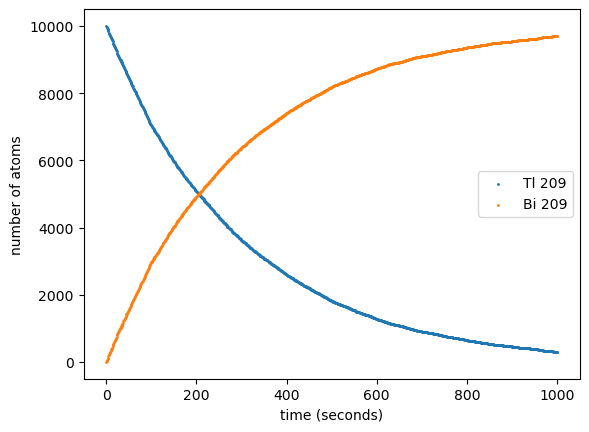

In [124]:
# determine constants

N_Pb = 10000
N_Bi209 = 0
tau = 3.3*60 # half-life of T1 in seconds

# time
h = 1 # time-step
tmax = 1000

# probability of decay
p = 1-2**(-h/tau)

# create arrays to loop through
tpts = np.arange(0.0, tmax+h, h)
Pb_pts = []
Bi209_pts = []

# loop through points
for i in tpts:
    Pb_pts.append(N_Pb)
    Bi209_pts.append(N_Bi209)

    # determine how many points decay
    decay = 0
    for i in range(N_Pb):
        if random.random() < p:
            decay += 1
    # change the number of atoms
    N_Pb -= decay
    N_Bi209 += decay 


# graph overall results
plt.scatter(tpts, Pb_pts, s=1, label="Tl 209")
plt.scatter(tpts, Bi209_pts, s=1, label="Bi 209")
plt.legend()
plt.xlabel('time (seconds)')
plt.ylabel('number of atoms')
plt.show()

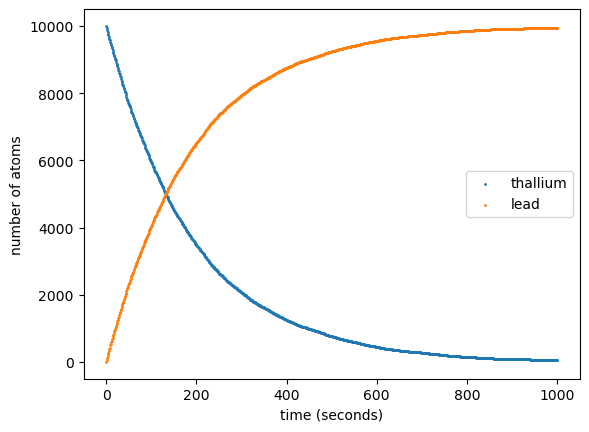

In [125]:
# part b

# determine constants
N_Tl = 10000
N_Pb = 0
tau = 2.2*60 # half-life of thallium in seconds

# time
h = 1 # time-step
tmax = 1000

# probability of decay
p = 1-2**(-h/tau)

# create arrays to loop through
tpts = np.arange(0.0, tmax+h, h)
Tl_pts = []
Pb_pts = []

# loop through points
for i in tpts:
    Tl_pts.append(N_Tl)
    Pb_pts.append(N_Pb)

    # determine how many points decay
    decay = 0
    for i in range(N_Tl):
        if random.random() < p:
            decay += 1
    # change the number of atoms
    N_Tl -= decay
    N_Pb += decay 


# graph overall results
plt.scatter(tpts, Tl_pts, s=1, label="thallium")
plt.scatter(tpts, Pb_pts, s=1, label="lead")
plt.legend()
plt.xlabel('time (seconds)')
plt.ylabel('number of atoms')
plt.show()

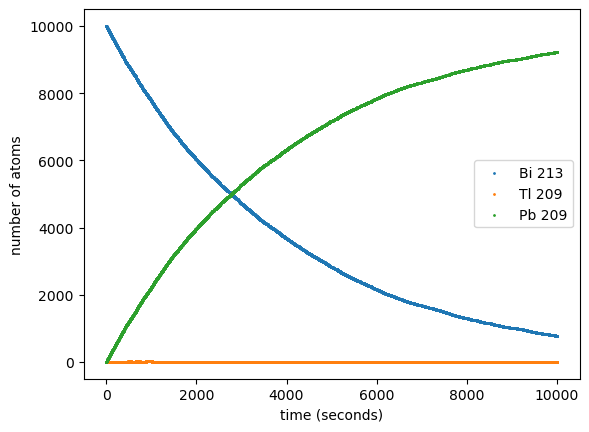

In [117]:
# part c

# determine constants

N_Bi213 = 10000
N_Tl = 0
N_Pb = 0
tau_Bi213 = 46.0*60 # half-life of Bi213 in seconds
tau_Tl = 2.2*60 # half-life of Tl in seconds

# time
h = 1 # time-step
tmax = 10000

# probability of decay
p_Bi213 = 1-2**(-h/tau_Bi213)
p_Tl = 1-2**(-h/tau_Tl)

# create arrays to loop through
tpts = np.arange(0.0, tmax+h, h)
Bi213_pts = []
Tl_pts = []
Pb_pts = []

# loop through points
for t in tpts:
    Bi213_pts.append(N_Bi213)
    Tl_pts.append(N_Tl)
    Pb_pts.append(N_Pb)

    # Bi decay
    decay_Bi = 0
    to_Tl = 0
    to_Pb = 0

    for j in range(N_Bi213):
        if random.random() < p_Bi213: # will it decay?
            decay_Bi += 1

            # conditionals for Tl
            if random.random() < 0.9791: #which way?
                to_Pb += 1
            else:
                to_Tl += 1

    # Tl decay
    decay_Tl = 0
    for k in range(N_Tl):
        if random.random() < p_Tl:
            decay_Tl += 1

    # update all populations
    N_Bi213 -= decay_Bi
    N_Tl += to_Tl - decay_Tl
    N_Pb += to_Pb + decay_Tl

    #print(N_Bi213, N_Tl, N_Pb)
        


# graph overall results
plt.scatter(tpts, Bi213_pts, s=1, label="Bi 213")
plt.scatter(tpts, Tl_pts, s=1, label="Tl 209")
plt.scatter(tpts, Pb_pts, s=1, label="Pb 209")

plt.legend()
plt.xlabel('time (seconds)')
plt.ylabel('number of atoms')
plt.show()

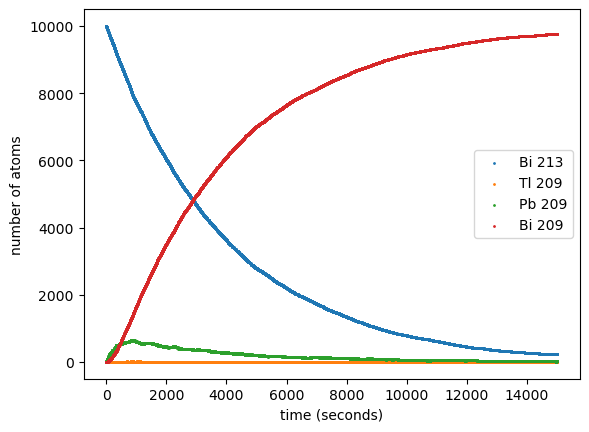

In [133]:
# all together now!
# determine constants

# initialize populations
N_Bi213 = 10000
N_Tl = 0
N_Pb = 0
N_Bi209 = 0

# half-lives
tau_Bi213 = 46.0*60 # half-life of Bi213 in seconds
tau_Tl = 2.2*60 # half-life of Tl in seconds
tau_Pb = 3.3*60 # half-life of Pb in seconds

# time
h = 1 # time-step
tmax = 15000

# probabilities of decay
p_Bi213 = 1-2**(-h/tau_Bi213)
p_Tl = 1-2**(-h/tau_Tl)
p_Pb = 1-2**(-h/tau_Pb)

# create storage arrays to loop through
tpts = np.arange(0.0, tmax+h, h)
Bi213_pts = []
Tl_pts = []
Pb_pts = []
Bi209_pts = []

# MAIN LOOP
for t in tpts:

    # current populations
    Bi213_pts.append(N_Bi213)
    Tl_pts.append(N_Tl)
    Pb_pts.append(N_Pb)
    Bi209_pts.append(N_Bi209)

    # decays based on current populations

    # Bi 213 decay
    decay_Bi = np.random.binomial(N_Bi213, p_Bi213)
    to_Tl = np.random.binomial(decay_Bi, 0.0209)
    to_Pb = decay_Bi - to_Tl

    # Tl decays
    decay_Tl = np.random.binomial(N_Tl, p_Tl)

    # Pb decays
    decay_Pb = np.random.binomial(N_Pb, p_Pb)

    # update all
    N_Bi213 -= decay_Bi
    N_Tl += to_Tl - decay_Tl
    N_Pb += to_Pb + decay_Tl - decay_Pb
    N_Bi209 += decay_Pb




# graph overall results
plt.scatter(tpts, Bi213_pts, s=1, label="Bi 213")
plt.scatter(tpts, Tl_pts, s=1, label="Tl 209")
plt.scatter(tpts, Pb_pts, s=1, label="Pb 209")
plt.scatter(tpts, Bi209_pts, s=1, label="Bi 209")

plt.legend()
plt.xlabel('time (seconds)')
plt.ylabel('number of atoms')
plt.show()

#### Explanation: 

Using half-lives given in the book
this is weird

for part b I just assumed I was starting with all 10000 atoms

### Problem 5: Exercise 10.4, page 463

In [ ]:


def nonuniform(tau):
    z = random.random()
    return -(1/(np.log(2)/tau))*np.log(1-z)

#### Explanation: 